## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Section 2 Fall 2023)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of 100 points possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpretting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructing clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1 (30 points)**: In this question, you're going to model the dynamics of a neuron when it's given a constant current input. When a neuron receives sufficient excitatory input, sodium channels can become activated leading to an sudden influx of positive charges, later balanced out by an outflux of potassium. This leads to a "spike" in the neuron's membrane potential, a.k.a., an action potential. The FitzHugh-Nagumo Model ([read more](http://www.scholarpedia.org/article/FitzHugh-Nagumo_model)) provides a simple description of this dynamics, shown in the following equations:

$$ \frac{dV}{dt} = V - \frac{V^3}{3} - W + I $$
$$ \frac{dW}{dt} = \phi(V+a-bW) $$

where $V$ is the membrane potential (sometimes referred to as the activation variable), $W$ is a recovery variable, and $I$ is the magnitude of an current input. Parameters $\phi$, $a$, $b$ control the time scales of the recovery of the membrane potential relative to the sodium activation. 

For this problem, we are intereseted in the dynamics of the model given the following paramters:

* $I=1$
* $\phi=0.08$
* $a=0.7$
* $b=0.8$

Solve this neuronal dynamic model using `solve_ivp`. Assuming the following initial conditions:

* $V(0) = 0.1$
* $W(0) = 0.1$

Evolve the model for 200 (ms) using a timestep of $\Delta t = 0.01$ (ms).

**Code you need to write to solve this problem**:
* A function that takes in a set of time values as well as the current values for $V$ and $W$ and **returns** the derivatives for each variable, $\frac{dV}{dt}$ and $\frac{dW}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* A set of variables for storing your initial conditions, $V_0$ and $W_0$, set to the correct initial values.
* A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* Code that unpacks the solution so that you can plot it.

**Note**: you can either use "`args`" argument for `solve_ivp` to provide the parameter values for $I$, $\phi$, $a$, and $b$ or you can directly code them into the derivatives function. 

In [ ]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [8]:
### ANSWER ###
# Rubric:
#  - import the models correctly (2 pts)
#  - any attempt to write the derivatives function (3 pts)
#  - getting the derivatives equations correct in the function (5 pts)
#  - getting the input, output correct for the function (5 pts)
#  - setting the parameters and initial conditions correctly (5 pts)
#  - setting the time array correctly (2 pts)
#  - using solve_ivp correctly (5 pts)
#  - unpacking the solution correctly (3 pts)

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals, I, phi, a, b):
    V, W = vals
    dVdt = V - V**3/3 - W + I
    dWdt = phi*(V+a-b*W)
    return dVdt, dWdt

# parameters
a = 0.7
b = 0.8
phi = 0.08
I = 1

# Solve the system
V0 = 0.1
W0 = 0.1

ICs = [V0, W0]
t = np.arange(0, 200, 0.01)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t,args=(I,phi,a,b))
V = sol.y[0,:]
W = sol.y[1,:]

print(V)

[0.1        0.11004338 0.12018059 ... 1.00768744 1.0066026  1.00551439]


&#9989;&nbsp; **Question 2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, humus, dead trees, and living trees as a function time. Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

If all goes well, you should end up with something that looks like this:

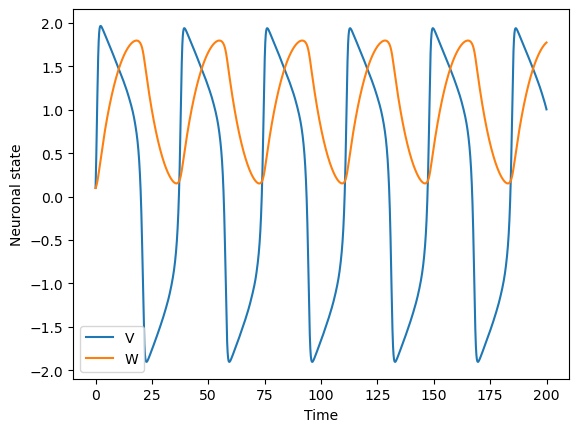

In [6]:
# put your code here

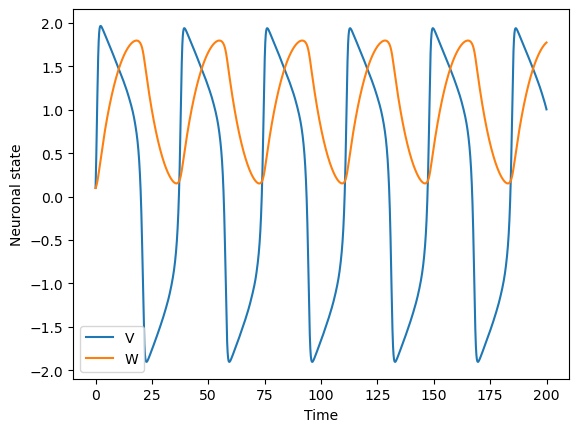

In [9]:
### ANSWER ###
# Rubric:
#  - plotting the two lines correctly (6 pts)
#  - labeling the axes and showing the legends (4 pts)
# Import needed modules
import matplotlib.pyplot as plt


plt.figure(1)
plt.plot(t,V,label="V")
plt.plot(t,W,label="W")
plt.xlabel("Time")
plt.ylabel("Neuronal state")
plt.legend()



## Part 2: Data Visualization (50 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 30 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. 

&#9989;&nbsp; **Question 2 (20 points total)**: Grade the visualization using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (4 Points)** 
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

### Visualizations to Choose From


**Visualization 1**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (3).png?raw=true">

**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true">

**Visualization 3**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/badGraphic.png?raw=true">

**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (7).png?raw=true">

**Visualization 5**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (2).png?raw=true">

**Visualization 6**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true">

**Visualization 7**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (8).png?raw=true">

**Visualization 8**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.33.22 PM.png?raw=true">

### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations!



**QUESTION 1 RESPONSES HERE**

**QUESTION 2 RESPONSES HERE**